## *Librerías*

In [1]:
import io
import json
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from fitter import Fitter
from ucimlrepo import fetch_ucirepo

**Aclaración Metodológica:** Este laboratorio fue desarrollado utilizando la metodología de **Vibe Coding** con asistencia de Inteligencia Artificial (GitHub Copilot / GPT-5.3-Codex), priorizando el diseño de la arquitectura (Engine/Runner) y el rigor matemático de la *Física de Datos* sobre la escritura manual de sintaxis.

## Funciones 

In [2]:
class TimeSeriesEngine:
    """Engine for Lab 2 time-series operations on EUR/USD data."""

    def __init__(self, data_frame):
        self.DataFrame = data_frame.copy()

    @staticmethod
    def _to_pascal_case(name):
        parts = re.split(r"[^A-Za-z0-9]+", str(name))
        parts = [part for part in parts if part]
        return "".join(part[:1].upper() + part[1:] for part in parts)

    @classmethod
    def from_csv(cls, csv_path_or_url):
        data_frame = pd.read_csv(csv_path_or_url)
        if "Unnamed: 0" in data_frame.columns:
            data_frame = data_frame.drop(columns=["Unnamed: 0"])
        return cls(data_frame)

    def normalize_columns_pascal_case(self):
        rename_map = {col: self._to_pascal_case(col) for col in self.DataFrame.columns}
        self.DataFrame = self.DataFrame.rename(columns=rename_map)
        return self.DataFrame

    def set_time_index(self, time_column="Time"):
        self.DataFrame[time_column] = pd.to_datetime(self.DataFrame[time_column], errors="coerce")
        self.DataFrame = self.DataFrame.set_index(time_column).sort_index()
        return self.DataFrame

    def get_data_frame_info(self):
        return {
            "Shape": {
                "Rows": int(self.DataFrame.shape[0]),
                "Columns": int(self.DataFrame.shape[1])
            },
            "Dtypes": {col: str(dtype) for col, dtype in self.DataFrame.dtypes.items()}
        }

    def get_null_nan_report(self):
        null_counts = self.DataFrame.isna().sum().to_dict()
        return {
            "NullOrNaNByColumn": {k: int(v) for k, v in null_counts.items()},
            "TotalNullOrNaN": int(self.DataFrame.isna().sum().sum())
        }

    def keep_only_close_price(self, close_column="Close"):
        self.DataFrame = self.DataFrame[[close_column]].copy()
        return self.DataFrame

    def add_diff_price(self, close_column="Close", diff_column="DiffPrice"):
        self.DataFrame[diff_column] = self.DataFrame[close_column].diff()
        return self.DataFrame

    def get_best_distribution(self, column="DiffPrice", distributions=None):
        if distributions is None:
            distributions = ["gamma", "lognorm", "beta", "burr", "norm"]

        sample = self.DataFrame[column].dropna().values
        fitter = Fitter(sample, distributions=distributions)
        fitter.fit()

        best = fitter.get_best(method="sumsquare_error")
        best_name = next(iter(best))
        return {
            "BestDistribution": best_name,
            "Parameters": {k: float(v) for k, v in best[best_name].items()},
            "AllSSE": {k: float(v) for k, v in fitter.summary()["sumsquare_error"].to_dict().items()}
        }

    def filter_year(self, year):
        self.DataFrame = self.DataFrame[self.DataFrame.index.year == year].copy()
        return self.DataFrame

    def grouped_mean_close(self, close_column="Close"):
        return {
            "15D": self.DataFrame.groupby(pd.Grouper(freq="15D"))[close_column].mean(),
            "1W": self.DataFrame.groupby(pd.Grouper(freq="1W"))[close_column].mean(),
            "1M": self.DataFrame.groupby(pd.Grouper(freq="ME"))[close_column].mean()
        }

    def monthly_histograms(self, year, close_column="Close", output_dir="artifacts/lab02_monthly_hist"):
        os.makedirs(output_dir, exist_ok=True)
        data_year = self.DataFrame[self.DataFrame.index.year == year]
        saved_paths = []

        for month in range(1, 13):
            month_data = data_year[data_year.index.month == month][close_column].dropna()
            if month_data.empty:
                continue

            plt.figure(figsize=(8, 4))
            plt.hist(month_data, bins=30, color="#2a9d8f", edgecolor="white", alpha=0.9)
            plt.title(f"Histogram of {close_column} - {year}-{month:02d}")
            plt.xlabel(close_column)
            plt.ylabel("Frequency")
            file_path = os.path.join(output_dir, f"hist_{year}_{month:02d}.png")
            plt.tight_layout()
            plt.savefig(file_path)
            plt.close()
            saved_paths.append(file_path)

        return saved_paths
    
class FeatureEngineeringEngine:
    """Engine for Lab 2 preprocessing operations on the breast cancer dataset."""

    def __init__(self, features, targets):
        self.Features = features.copy()
        self.Targets = targets.copy()
        self.SystemDataFrame = None

    @staticmethod
    def _to_pascal_case(name):
        parts = re.split(r"[^A-Za-z0-9]+", str(name))
        parts = [part for part in parts if part]
        return "".join(part[:1].upper() + part[1:] for part in parts)

    def build_system_dataframe(self, target_column_name="Diagnosis"):
        target_series = self.Targets.squeeze().rename(target_column_name)
        self.SystemDataFrame = pd.concat([self.Features, target_series], axis=1)
        return self.SystemDataFrame

    def normalize_columns_pascal_case(self):
        if self.SystemDataFrame is None:
            raise ValueError("SystemDataFrame is not initialized. Run build_system_dataframe first.")
        rename_map = {col: self._to_pascal_case(col) for col in self.SystemDataFrame.columns}
        self.SystemDataFrame = self.SystemDataFrame.rename(columns=rename_map)
        return self.SystemDataFrame

    def map_diagnosis_numeric(self, source_column="Diagnosis", target_column="DiagnosisNumeric"):
        if self.SystemDataFrame is None:
            raise ValueError("SystemDataFrame is not initialized. Run build_system_dataframe first.")
        mapping = {"B": 0, "M": 1}
        self.SystemDataFrame[target_column] = self.SystemDataFrame[source_column].map(mapping)
        return self.SystemDataFrame

    def get_null_profile(self):
        if self.SystemDataFrame is None:
            raise ValueError("SystemDataFrame is not initialized. Run build_system_dataframe first.")
        null_counts = self.SystemDataFrame.isna().sum().to_dict()
        return {
            "NullCountByColumn": {k: int(v) for k, v in null_counts.items()},
            "TotalNullCount": int(self.SystemDataFrame.isna().sum().sum())
        }

    def get_target_distribution(self, target_column="Diagnosis"):
        if self.SystemDataFrame is None:
            raise ValueError("SystemDataFrame is not initialized. Run build_system_dataframe first.")
        distribution = self.SystemDataFrame[target_column].value_counts(dropna=False).to_dict()
        return {str(k): int(v) for k, v in distribution.items()}

    def zscore_normalize_features(self, exclude_columns=None):
        """Applies vectorized z-score normalization to numeric columns."""
        if self.SystemDataFrame is None:
            raise ValueError("SystemDataFrame is not initialized. Run build_system_dataframe first.")

        if exclude_columns is None:
            exclude_columns = []

        numeric_cols = self.SystemDataFrame.select_dtypes(include=[np.number]).columns
        cols_to_normalize = [col for col in numeric_cols if col not in set(exclude_columns)]

        means = self.SystemDataFrame[cols_to_normalize].mean(axis=0)
        stds = self.SystemDataFrame[cols_to_normalize].std(axis=0, ddof=0)
        stds = stds.replace(0, np.nan)

        self.SystemDataFrame.loc[:, cols_to_normalize] = (
            (self.SystemDataFrame[cols_to_normalize] - means) / stds
        )
        return self.SystemDataFrame

    def add_grouped_feature_averages_regex(self):
        """Groups feature triplets (1,2,3) by regex pattern and stores their row-wise means."""
        if self.SystemDataFrame is None:
            raise ValueError("SystemDataFrame is not initialized. Run build_system_dataframe first.")

        base_to_group = {
            "Radius": "RadiusMean",
            "Texture": "TextureMean",
            "Perimeter": "PerimeterMean",
            "Area": "AreaMean",
            "Smoothness": "SmoothnessMean",
            "Compactness": "CompactnessMean",
            "Concavity": "ConcavityMean",
            "ConcavePoints": "ConcavePointsMean",
            "Symmetry": "SymmetryMean",
            "FractalDimension": "FractalDimensionMean"
        }

        grouped_sources = {}
        for base_name, grouped_name in base_to_group.items():
            pattern = re.compile(rf"^{base_name}(1|2|3)$")
            matched_cols = [col for col in self.SystemDataFrame.columns if pattern.match(col)]
            if not matched_cols:
                continue

            self.SystemDataFrame[grouped_name] = self.SystemDataFrame[matched_cols].mean(axis=1)
            grouped_sources[grouped_name] = matched_cols

        return self.SystemDataFrame, grouped_sources

    def detect_outliers_iqr(self, column):
        """Returns row indices outside the IQR bounds [Q1 - 1.5*IQR, Q3 + 1.5*IQR]."""
        if self.SystemDataFrame is None:
            raise ValueError("SystemDataFrame is not initialized. Run build_system_dataframe first.")

        series = self.SystemDataFrame[column].dropna()
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        mask = (self.SystemDataFrame[column] < lower) | (self.SystemDataFrame[column] > upper)
        return self.SystemDataFrame.index[mask].tolist()

    def detect_outliers_zscore(self, column, threshold=3.0):
        """Returns row indices where abs(z-score) > threshold."""
        if self.SystemDataFrame is None:
            raise ValueError("SystemDataFrame is not initialized. Run build_system_dataframe first.")

        series = self.SystemDataFrame[column]
        mu = series.mean()
        sigma = series.std(ddof=0)
        if sigma == 0 or np.isnan(sigma):
            return []

        z_scores = (series - mu) / sigma
        mask = z_scores.abs() > threshold
        return self.SystemDataFrame.index[mask].tolist()

    def remove_outliers(self, outlier_indices):
        """Removes outlier rows from SystemDataFrame and returns the cleaned DataFrame."""
        if self.SystemDataFrame is None:
            raise ValueError("SystemDataFrame is not initialized. Run build_system_dataframe first.")

        self.SystemDataFrame = self.SystemDataFrame.drop(index=outlier_indices, errors="ignore")
        return self.SystemDataFrame

# Lab 2 Parte 1 - Series de Tiempo

> 1. Leer el dataset desde el github.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv"

RAW_DIR = Path("./data")
RAW_DIR.mkdir(parents=True, exist_ok=True)
RAW_PATH = RAW_DIR / "eur_usd.csv"

try:
    df_raw = pd.read_csv(DATA_URL)
    
    # Persist the matter locally within the lab folder
    df_raw.to_csv(RAW_PATH, index=False)

    print("--- Respuestas al Laboratorio 2 Parte 1 ---")
    print(f"1. Dataset leído exitosamente desde GitHub.")
    print(f"   Localización local: {RAW_PATH}")
    print(f"   Dimensiones del sistema: {df_raw.shape[0]} filas, {df_raw.shape[1]} columnas.")
    display(df_raw.head())

except Exception as e:
    print(f"Error en la adquisición de datos: {e}")

--- Respuestas al Laboratorio 2 Parte 1 ---
1. Dataset leído exitosamente desde GitHub.
   Localización local: data/eur_usd.csv
   Dimensiones del sistema: 5000 filas, 13 columnas.


,Unnamed: 0,time,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
0,0,2022-07-25 13:00:00,1.02427,1.02430,1.02145,1.02345,3927,8,0,1.023860,-0.00046,-0.00082,-0.000640
1,1,2022-07-25 14:00:00,1.02345,1.02578,1.02288,1.02299,5344,8,0,1.023220,-0.00046,-0.00082,-0.000640
2,2,2022-07-25 15:00:00,1.02303,1.02476,1.02230,1.02457,5524,8,0,1.023800,0.00158,-0.00042,0.000580
3,3,2022-07-25 16:00:00,1.02454,1.02548,1.02355,1.02485,5234,8,0,1.024695,0.00028,0.00151,0.000895
4,4,2022-07-25 17:00:00,1.02485,1.02514,1.02030,1.02181,9031,7,0,1.023330,-0.00304,0.00031,-0.001365


> 2. Definir como indice la columna time.

In [4]:
engine = TimeSeriesEngine(df_raw)
engine.normalize_columns_pascal_case()
engine.set_time_index("Time")

print("2. La columna Time fue definida como índice temporal del sistema.")
print(f"   Tipo de índice: {type(engine.DataFrame.index).__name__}")
print(engine.DataFrame.head())

2. La columna Time fue definida como índice temporal del sistema.
   Tipo de índice: DatetimeIndex
                     Unnamed0     Open     High      Low    Close  TickVolume  \
Time                                                                            
2022-07-25 13:00:00         0  1.02427  1.02430  1.02145  1.02345        3927   
2022-07-25 14:00:00         1  1.02345  1.02578  1.02288  1.02299        5344   
2022-07-25 15:00:00         2  1.02303  1.02476  1.02230  1.02457        5524   
2022-07-25 16:00:00         3  1.02454  1.02548  1.02355  1.02485        5234   
2022-07-25 17:00:00         4  1.02485  1.02514  1.02030  1.02181        9031   

                     Spread  RealVolume  MeanCloseOpen  DiffClose  DiffOpen  \
Time                                                                          
2022-07-25 13:00:00       8           0       1.023860   -0.00046  -0.00082   
2022-07-25 14:00:00       8           0       1.023220   -0.00046  -0.00082   
2022-07-25 15:00:

> 3. Obtenga información del data frame.

In [5]:
frame_info = engine.get_data_frame_info()

print("3. Información estructural del DataFrame:")
print(f"   Filas: {frame_info['Shape']['Rows']}")
print(f"   Columnas: {frame_info['Shape']['Columns']}")
print("   Tipos de datos:")
for col, dtype in frame_info["Dtypes"].items():
    print(f"   - {col}: {dtype}")

3. Información estructural del DataFrame:
   Filas: 5000
   Columnas: 12
   Tipos de datos:
   - Unnamed0: int64
   - Open: float64
   - High: float64
   - Low: float64
   - Close: float64
   - TickVolume: int64
   - Spread: int64
   - RealVolume: int64
   - MeanCloseOpen: float64
   - DiffClose: float64
   - DiffOpen: float64
   - DiffMeanCloseOpen: float64


> 4. Determine si hay null, nan en el data frame.

In [6]:
null_report = engine.get_null_nan_report()

print("4. Evaluación de valores null/NaN:")
print(f"   Total null/NaN: {null_report['TotalNullOrNaN']}")
print("   Conteo por columna:")
for col, count in null_report["NullOrNaNByColumn"].items():
    print(f"   - {col}: {count}")

4. Evaluación de valores null/NaN:
   Total null/NaN: 0
   Conteo por columna:
   - Unnamed0: 0
   - Open: 0
   - High: 0
   - Low: 0
   - Close: 0
   - TickVolume: 0
   - Spread: 0
   - RealVolume: 0
   - MeanCloseOpen: 0
   - DiffClose: 0
   - DiffOpen: 0
   - DiffMeanCloseOpen: 0


> 5. Emplea la notacion Pascal Case y trabaja solo con la columa del precio de cierre del eur/usd.

In [7]:
engine.normalize_columns_pascal_case()
engine.keep_only_close_price("Close")

print("5. Se mantiene notación PascalCase y se trabaja solo con el precio de cierre EUR/USD.")
print(f"   Columnas activas: {engine.DataFrame.columns.tolist()}")
print(engine.DataFrame.head())

5. Se mantiene notación PascalCase y se trabaja solo con el precio de cierre EUR/USD.
   Columnas activas: ['Close']
                       Close
Time                        
2022-07-25 13:00:00  1.02345
2022-07-25 14:00:00  1.02299
2022-07-25 15:00:00  1.02457
2022-07-25 16:00:00  1.02485
2022-07-25 17:00:00  1.02181


> 6. Determinar cual es la mejor distribución estadística que se ajusta a la diferencia del precio de cierre cada hora (DiffPrice):
> 
> - Determine la diferencia de precio entre horas, agregue una nueva columna llamada DiffPrice.
> - Para la nueva columna construya un histograma de los datos.
> - Determine la mejor distribucion estadística (fitter) entre [gamma, lognorm, beta, burr, norm].

6.1 Se calculó la diferencia horaria en la columna DiffPrice.
                       Close  DiffPrice
Time                                   
2022-07-25 13:00:00  1.02345        NaN
2022-07-25 14:00:00  1.02299   -0.00046
2022-07-25 15:00:00  1.02457    0.00158
2022-07-25 16:00:00  1.02485    0.00028
2022-07-25 17:00:00  1.02181   -0.00304


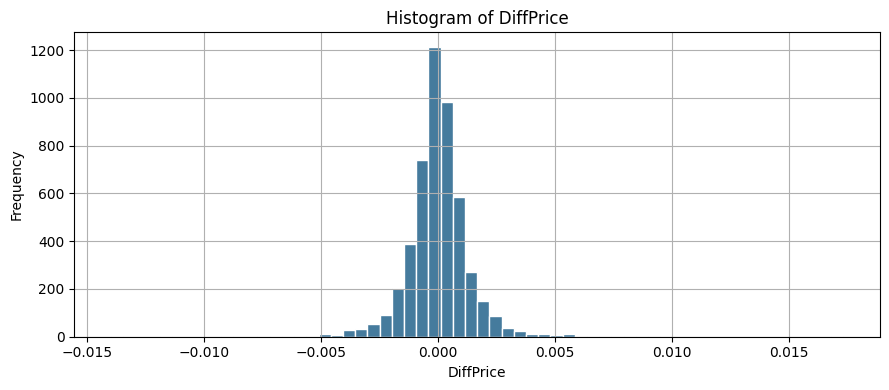

6.2 Histograma de DiffPrice generado.


2026-04-18 16:11:09.876 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted norm: error=106744.023571, AIC=-51505.72, KS=0.0905
2026-04-18 16:11:10.018 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted gamma: error=923360.482403, AIC=-17723.24, KS=0.5914
2026-04-18 16:11:10.104 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted beta: error=106677.525909, AIC=-51503.23, KS=0.0908
2026-04-18 16:11:10.234 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted lognorm: error=106500.661168, AIC=-51509.77, KS=0.0916
2026-04-18 16:11:10.271 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted burr: error=721804.561088, AIC=-37765.25, KS=0.3864


6.3 Mejor distribución ajustada (fitter):
{'BestDistribution': 'lognorm', 'Parameters': {'s': 0.009509964461157715, 'loc': -0.1471693008245066, 'scale': 0.14717494036949658}, 'AllSSE': {'lognorm': 106500.66116836156, 'beta': 106677.525909416, 'norm': 106744.02357126417, 'burr': 721804.5610880618, 'gamma': 923360.4824031572}}


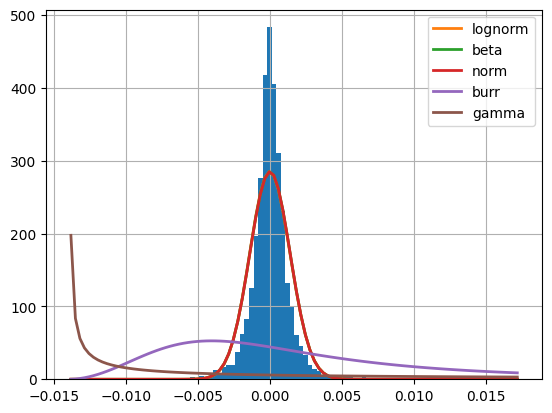

In [8]:
engine.add_diff_price(close_column="Close", diff_column="DiffPrice")

print("6.1 Se calculó la diferencia horaria en la columna DiffPrice.")
print(engine.DataFrame[["Close", "DiffPrice"]].head())

plt.figure(figsize=(9, 4))
engine.DataFrame["DiffPrice"].dropna().hist(bins=60, color="#457b9d", edgecolor="white")
plt.title("Histogram of DiffPrice")
plt.xlabel("DiffPrice")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
print("6.2 Histograma de DiffPrice generado.")

best_fit = engine.get_best_distribution("DiffPrice", ["gamma", "lognorm", "beta", "burr", "norm"])
print("6.3 Mejor distribución ajustada (fitter):")
print(best_fit)

> 7. Para el data frame, seleccionemos solo los datos del 2023.

In [9]:
engine_2023 = TimeSeriesEngine(engine.DataFrame.copy())
engine_2023.filter_year(2023)

print("7. Se seleccionaron únicamente los datos correspondientes al año 2023.")
print(f"   Filas 2023: {engine_2023.DataFrame.shape[0]}")
print(engine_2023.DataFrame.head())

7. Se seleccionaron únicamente los datos correspondientes al año 2023.
   Filas 2023: 2278
                       Close  DiffPrice
Time                                   
2023-01-02 00:00:00  1.06796   -0.00200
2023-01-02 01:00:00  1.06965    0.00169
2023-01-02 02:00:00  1.07058    0.00093
2023-01-02 03:00:00  1.06896   -0.00162
2023-01-02 04:00:00  1.06880   -0.00016


> 8. El comando groupby permite agrupar los datos con la periodicidad deseada: 15 dias, 1 semana, y 1 mes. Determina el promedio.

In [10]:
grouped_means = engine_2023.grouped_mean_close("Close")

print("8. Promedios de Close por periodicidad (15 días, 1 semana, 1 mes):")
for period, series in grouped_means.items():
    print(f"\n   {period} -> primeras filas")
    print(series.head())

8. Promedios de Close por periodicidad (15 días, 1 semana, 1 mes):

   15D -> primeras filas
Time
2023-01-02    1.069361
2023-01-17    1.085565
2023-02-01    1.077679
2023-02-16    1.063150
2023-03-03    1.063186
Freq: 15D, Name: Close, dtype: float64

   1W -> primeras filas
Time
2023-01-08    1.059972
2023-01-15    1.076002
2023-01-22    1.082041
2023-01-29    1.088414
2023-02-05    1.089281
Freq: W-SUN, Name: Close, dtype: float64

   1M -> primeras filas
Time
2023-01-31    1.077463
2023-02-28    1.071167
2023-03-31    1.070874
2023-04-30    1.096051
2023-05-31    1.098980
Freq: ME, Name: Close, dtype: float64


> 9. Para los datos asociados a los meses de 2023, construya un histograma para cada mes.

In [11]:
hist_paths = engine_2023.monthly_histograms(2023, close_column="Close", output_dir="../artifacts/lab02_monthly_hist")

print("9. Histogramas mensuales para 2023 generados.")
print(f"   Total de histogramas guardados: {len(hist_paths)}")
print("   Primeros archivos:")
for path in hist_paths[:5]:
    print(f"   - {path}")

9. Histogramas mensuales para 2023 generados.
   Total de histogramas guardados: 5
   Primeros archivos:
   - ../artifacts/lab02_monthly_hist/hist_2023_01.png
   - ../artifacts/lab02_monthly_hist/hist_2023_02.png
   - ../artifacts/lab02_monthly_hist/hist_2023_03.png
   - ../artifacts/lab02_monthly_hist/hist_2023_04.png
   - ../artifacts/lab02_monthly_hist/hist_2023_05.png


> Guardar artifacto con la mejor distribucion y parametros.

In [12]:
artifact_path = Path("../artifacts/02_eurusd_stats.json")
artifact_path.parent.mkdir(parents=True, exist_ok=True)
with open(artifact_path, "w", encoding="utf-8") as f:
    json.dump(best_fit, f, indent=2, ensure_ascii=False)

print("Resultado final: artifact de distribución guardado correctamente.")
print(f"Ruta: {artifact_path}")
print(f"Mejor distribución: {best_fit['BestDistribution']}")
artifact_path

Resultado final: artifact de distribución guardado correctamente.
Ruta: ../artifacts/02_eurusd_stats.json
Mejor distribución: lognorm


PosixPath('../artifacts/02_eurusd_stats.json')

# Lab 2 Part 2 - Breast Cancer Preprocessing (Phase A)

> 1. Leer los datos desde una página web.

In [13]:
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

engine = FeatureEngineeringEngine(X, y)
system_df = engine.build_system_dataframe(target_column_name="Diagnosis")

print("--- Respuestas al Laboratorio 2 Parte 2 ---")
print("1. Datos leídos desde página web usando ucimlrepo (id=17).")
print(f"   Registros: {system_df.shape[0]}, Columnas: {system_df.shape[1]}")
print(system_df.head())

--- Respuestas al Laboratorio 2 Parte 2 ---
1. Datos leídos desde página web usando ucimlrepo (id=17).
   Registros: 569, Columnas: 31
   radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3    11.42     20.38       77.58   386.1      0.14250       0.28390   
4    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...  texture3  \
0      0.3001          0.14710     0.2419             0.07871  ...     17.33   
1      0.0869          0.07017     0.1812             0.05667  ...     23.41   
2      0.1974          0.12790     0.2069             0.05999  ...     25.53   
3      0.2414          0.10520     0.2597             0.09744  ...     26.50   
4      0.1980          0.10430     0.1

> 2. Renombrar las columnas en formato PascalCase.

In [14]:
system_df = engine.normalize_columns_pascal_case()

print("2. Columnas renombradas en formato PascalCase.")
print("   Primeras 10 columnas:")
for col in system_df.columns.tolist()[:10]:
    print(f"   - {col}")

2. Columnas renombradas en formato PascalCase.
   Primeras 10 columnas:
   - Radius1
   - Texture1
   - Perimeter1
   - Area1
   - Smoothness1
   - Compactness1
   - Concavity1
   - ConcavePoints1
   - Symmetry1
   - FractalDimension1


> 3. Utilizar los métodos head(), tail(), describe() e info() para obtener información sobre el DataFrame.

In [15]:
print("3. Resumen del DataFrame con head(), tail(), describe() e info().")
print("\n3.1 head():")
display(system_df.head())

print("\n3.2 tail():")
display(system_df.tail())

print("\n3.3 describe(include='all'):")
display(system_df.describe(include="all"))

print("\n3.4 info():")
buffer = io.StringIO()
system_df.info(buf=buffer)
print(buffer.getvalue())

3. Resumen del DataFrame con head(), tail(), describe() e info().

3.1 head():


,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,Symmetry1,FractalDimension1,...,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M



3.2 tail():


,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,Symmetry1,FractalDimension1,...,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3,Diagnosis
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,M
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,M
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,M
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,M
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,B



3.3 describe(include='all'):


,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,Symmetry1,FractalDimension1,...,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3,Diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,357
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN



3.4 info():
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Radius1            569 non-null    float64
 1   Texture1           569 non-null    float64
 2   Perimeter1         569 non-null    float64
 3   Area1              569 non-null    float64
 4   Smoothness1        569 non-null    float64
 5   Compactness1       569 non-null    float64
 6   Concavity1         569 non-null    float64
 7   ConcavePoints1     569 non-null    float64
 8   Symmetry1          569 non-null    float64
 9   FractalDimension1  569 non-null    float64
 10  Radius2            569 non-null    float64
 11  Texture2           569 non-null    float64
 12  Perimeter2         569 non-null    float64
 13  Area2              569 non-null    float64
 14  Smoothness2        569 non-null    float64
 15  Compactness2       569 non-null    float64
 16  Concavity2         569 n

> 4. Contabilizar la cantidad de valores nulos (null o NaN) en el DataFrame. Si se encuentran valores nulos, ¿qué estrategia propondrías para reemplazarlos?

In [16]:
null_profile = engine.get_null_profile()
total_nulls = null_profile["TotalNullCount"]

print("4. Conteo de valores null/NaN en el sistema:")
print(f"   Total null/NaN: {total_nulls}")
for col, count in null_profile["NullCountByColumn"].items():
    print(f"   - {col}: {count}")

if total_nulls > 0:
    print("   Estrategia propuesta: imputación por mediana (numéricas) y moda (categóricas).")
else:
    print("   No hay nulos; no se requiere imputación en esta fase.")

4. Conteo de valores null/NaN en el sistema:
   Total null/NaN: 0
   - Radius1: 0
   - Texture1: 0
   - Perimeter1: 0
   - Area1: 0
   - Smoothness1: 0
   - Compactness1: 0
   - Concavity1: 0
   - ConcavePoints1: 0
   - Symmetry1: 0
   - FractalDimension1: 0
   - Radius2: 0
   - Texture2: 0
   - Perimeter2: 0
   - Area2: 0
   - Smoothness2: 0
   - Compactness2: 0
   - Concavity2: 0
   - ConcavePoints2: 0
   - Symmetry2: 0
   - FractalDimension2: 0
   - Radius3: 0
   - Texture3: 0
   - Perimeter3: 0
   - Area3: 0
   - Smoothness3: 0
   - Compactness3: 0
   - Concavity3: 0
   - ConcavePoints3: 0
   - Symmetry3: 0
   - FractalDimension3: 0
   - Diagnosis: 0
   No hay nulos; no se requiere imputación en esta fase.


> 5. Identificar los valores únicos en la columna target que representan las etiquetas B y M.

In [17]:
target_column = "Diagnosis"
unique_labels = sorted(system_df[target_column].dropna().unique().tolist())

print("5. Valores únicos en la columna target (Diagnosis):")
for i, label in enumerate(unique_labels, start=1):
    print(f"   {i}. {label}")
unique_labels

5. Valores únicos en la columna target (Diagnosis):
   1. B
   2. M


['B', 'M']

> 6. Realizar un conteo de los casos etiquetados como B y M utilizando la librería seaborn y el método countplot().

6. Conteo de casos B y M con seaborn countplot().
   B (Benigno): 357
   M (Maligno): 212


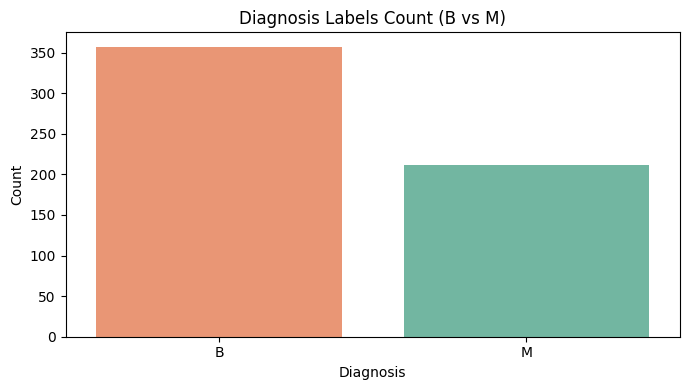

In [18]:
label_counts = system_df[target_column].value_counts()

print("6. Conteo de casos B y M con seaborn countplot().")
print(f"   B (Benigno): {int(label_counts.get('B', 0))}")
print(f"   M (Maligno): {int(label_counts.get('M', 0))}")

plt.figure(figsize=(7, 4))
sns.countplot(data=system_df, x=target_column, order=["B", "M"], hue=target_column, palette="Set2", legend=False)
plt.title("Diagnosis Labels Count (B vs M)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

> 7. Agregar una nueva columna llamada DiagnosisNumeric donde se asigna el valor 0 a la etiqueta B (Benigno) y el valor 1 a la etiqueta M (Maligno).

In [19]:
system_df = engine.map_diagnosis_numeric(source_column=target_column, target_column="DiagnosisNumeric")

print("7. Se creó la columna DiagnosisNumeric con mapeo B->0 y M->1.")
print(system_df[[target_column, "DiagnosisNumeric"]].head())
print("   Valores únicos en DiagnosisNumeric:", sorted(system_df["DiagnosisNumeric"].dropna().unique().tolist()))

artifact = {
    "NullProfile": null_profile,
    "TargetDistribution": engine.get_target_distribution(target_column=target_column)
}
artifact_dir_candidates = [Path("artifacts"), Path("../artifacts")]
artifact_dir = next((p for p in artifact_dir_candidates if p.exists()), artifact_dir_candidates[0])
artifact_path = artifact_dir / "02_cancer_profile.json"
artifact_path.parent.mkdir(parents=True, exist_ok=True)
with open(artifact_path, "w", encoding="utf-8") as f:
    json.dump(artifact, f, indent=2, ensure_ascii=False)

print(f"   Artifact generado: {artifact_path}")
artifact_path

7. Se creó la columna DiagnosisNumeric con mapeo B->0 y M->1.
  Diagnosis  DiagnosisNumeric
0         M                 1
1         M                 1
2         M                 1
3         M                 1
4         M                 1
   Valores únicos en DiagnosisNumeric: [0, 1]
   Artifact generado: ../artifacts/02_cancer_profile.json


PosixPath('../artifacts/02_cancer_profile.json')

> 8. Normalizar cada columna respecto a su media y desviación estándar utilizando la fórmula: (x - mean(x)) / std(x)

In [20]:
feature_columns = [
    col for col in system_df.select_dtypes(include=["number"]).columns
    if col != "DiagnosisNumeric"
]

system_df = engine.zscore_normalize_features(exclude_columns=["DiagnosisNumeric"])

z_means = system_df[feature_columns].mean(axis=0)
z_stds = system_df[feature_columns].std(axis=0, ddof=0)
verification_df = pd.DataFrame({"Mu": z_means, "Sigma": z_stds})

print("8. Normalización Z-score aplicada: (x - mean(x)) / std(x)")
print("   Verificación (primeras 10 columnas):")
display(verification_df.head(10))
print("   Max |mu|:", float(verification_df["Mu"].abs().max()))
print("   Max |sigma-1|:", float((verification_df["Sigma"] - 1.0).abs().max()))

8. Normalización Z-score aplicada: (x - mean(x)) / std(x)
   Verificación (primeras 10 columnas):


,Mu,Sigma
Radius1,-1.373633e-16,1.0
Texture1,6.868164e-17,1.0
Perimeter1,-1.248757e-16,1.0
Area1,-2.185325e-16,1.0
Smoothness1,-8.366672e-16,1.0
Compactness1,1.873136e-16,1.0
Concavity1,4.995028e-17,1.0
ConcavePoints1,-4.995028e-17,1.0
Symmetry1,1.748260e-16,1.0
FractalDimension1,4.745277e-16,1.0


   Max |mu|: 8.366671932500301e-16
   Max |sigma-1|: 2.220446049250313e-16


> 9. Agrupar características similares y calcular su promedio. Para las siguientes características: ['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', 'SymmetryMean', 'FractalDimensionMean'] Usa expresiones regulares para identificar patrones comunes, como radius1, radius2, radius3, etc., y calcular los promedios.

In [21]:
system_df, grouped_sources = engine.add_grouped_feature_averages_regex()

expected_grouped_cols = [
    "RadiusMean",
    "TextureMean",
    "PerimeterMean",
    "AreaMean",
    "SmoothnessMean",
    "CompactnessMean",
    "ConcavityMean",
    "ConcavePointsMean",
    "SymmetryMean",
    "FractalDimensionMean"
]
grouped_cols = [col for col in expected_grouped_cols if col in system_df.columns]

grouped_feature_means = {
    col: float(system_df[col].mean())
    for col in grouped_cols
}

grouped_artifact = {
    "GroupedFeatureColumns": grouped_cols,
    "GroupedFeatureMeans": grouped_feature_means,
    "GroupedFeatureSources": grouped_sources
}

artifact_dir_candidates = [Path("artifacts"), Path("../artifacts")]
artifact_dir = next((p for p in artifact_dir_candidates if p.exists()), artifact_dir_candidates[0])
grouped_artifact_path = artifact_dir / "02_cancer_grouped_features.json"
grouped_artifact_path.parent.mkdir(parents=True, exist_ok=True)

with open(grouped_artifact_path, "w", encoding="utf-8") as f:
    json.dump(grouped_artifact, f, indent=2, ensure_ascii=False)

print("9. Características agrupadas por regex y promediadas correctamente.")
for col in grouped_cols:
    print(f"   - {col}: media={grouped_feature_means[col]:.6f}")
print(f"   Artifact generado: {grouped_artifact_path}")
pd.DataFrame({"GroupedColumn": grouped_cols, "Mean": [grouped_feature_means[c] for c in grouped_cols]})

9. Características agrupadas por regex y promediadas correctamente.
   - RadiusMean: media=-0.000000
   - TextureMean: media=0.000000
   - PerimeterMean: media=-0.000000
   - AreaMean: media=-0.000000
   - SmoothnessMean: media=-0.000000
   - CompactnessMean: media=0.000000
   - ConcavityMean: media=0.000000
   - ConcavePointsMean: media=0.000000
   - SymmetryMean: media=0.000000
   - FractalDimensionMean: media=-0.000000
   Artifact generado: ../artifacts/02_cancer_grouped_features.json


,GroupedColumn,Mean
0,RadiusMean,-2.497514e-16
1,TextureMean,0.000000e+00
2,PerimeterMean,-2.122887e-16
3,AreaMean,-1.123881e-16
4,SmoothnessMean,-4.120898e-16
5,CompactnessMean,1.248757e-17
6,ConcavityMean,9.990056e-17
7,ConcavePointsMean,6.243785e-17
8,SymmetryMean,1.748260e-16
9,FractalDimensionMean,-2.497514e-17


> 10. Crear un gráfico donde se muestre el histograma de la columna RadiusMean separado por las etiquetas B y M, utilizando colores diferentes (naranja y azul, respectivamente) para cada diagnóstico.

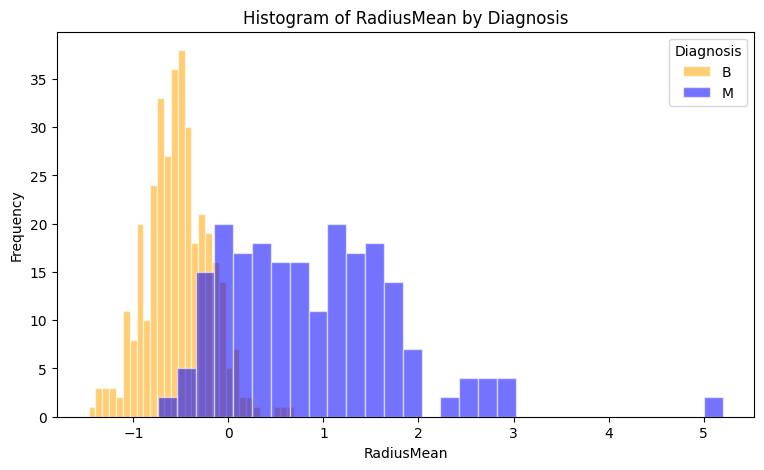

10. Histograma de RadiusMean separado por diagnóstico (B naranja, M azul) generado.
   Ruta: ../artifacts/hist_RadiusMean_Diagnosis.png


'../artifacts/hist_RadiusMean_Diagnosis.png'

In [22]:
from src.visuals import (
    plot_overlapping_hist_by_label,
    plot_multifeature_violin,
    plot_correlation_heatmap,
)

if "RadiusMean" not in system_df.columns:
    system_df, _ = engine.add_grouped_feature_averages_regex()

hist_path = plot_overlapping_hist_by_label(
    system_df,
    value_col="RadiusMean",
    label_col="Diagnosis",
    filename="hist_RadiusMean_Diagnosis.png",
    bins=30,
)

print("10. Histograma de RadiusMean separado por diagnóstico (B naranja, M azul) generado.")
print(f"   Ruta: {hist_path}")
hist_path

> 11. Generar gráficos de violín para múltiples características.

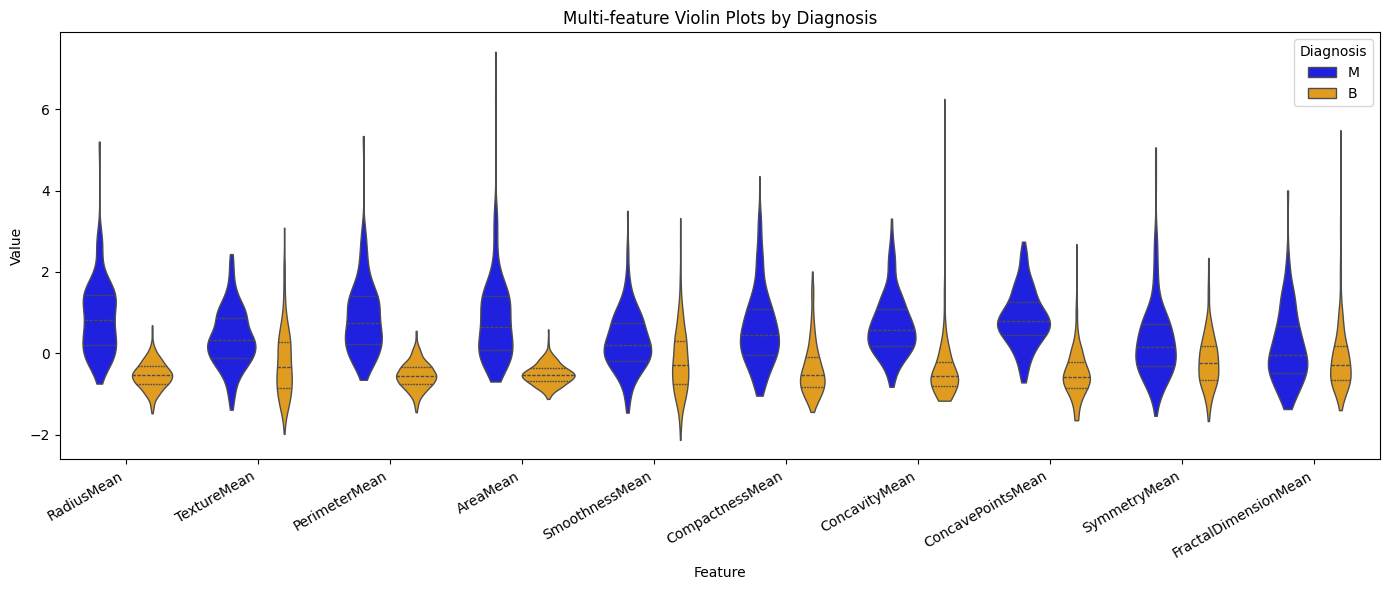

11. Gráficos de violín multicaracterística generados.
   Número de características: 10
   Ruta: ../artifacts/violin_grouped_features_diagnosis.png


'../artifacts/violin_grouped_features_diagnosis.png'

In [23]:
violin_features = [
    "RadiusMean",
    "TextureMean",
    "PerimeterMean",
    "AreaMean",
    "SmoothnessMean",
    "CompactnessMean",
    "ConcavityMean",
    "ConcavePointsMean",
    "SymmetryMean",
    "FractalDimensionMean",
]

violin_path = plot_multifeature_violin(
    system_df,
    feature_columns=violin_features,
    label_col="Diagnosis",
    filename="violin_grouped_features_diagnosis.png",
)

print("11. Gráficos de violín multicaracterística generados.")
print(f"   Número de características: {len(violin_features)}")
print(f"   Ruta: {violin_path}")
violin_path

> 12. Determinar y eliminar los valores atípicos (outliers) en la columna RadiusMean.

In [24]:
iqr_outliers = engine.detect_outliers_iqr("RadiusMean")
z_outliers = engine.detect_outliers_zscore("RadiusMean", threshold=3.0)
combined_outliers = sorted(set(iqr_outliers).union(z_outliers))

pre_remove_n = int(system_df.shape[0])

system_df = engine.remove_outliers(combined_outliers)
post_remove_n = int(system_df.shape[0])
outliers_removed_count = pre_remove_n - post_remove_n

print("12. Detección y remoción de outliers en RadiusMean (IQR y Z-score).")
print(f"    Outliers IQR: {len(iqr_outliers)}")
print(f"    Outliers Z-score: {len(z_outliers)}")
print(f"    Outliers combinados removidos: {len(combined_outliers)}")
print(f"    Filas antes: {pre_remove_n}")
print(f"    Filas después: {post_remove_n}")

12. Detección y remoción de outliers en RadiusMean (IQR y Z-score).
    Outliers IQR: 22
    Outliers Z-score: 6
    Outliers combinados removidos: 22
    Filas antes: 569
    Filas después: 547


> 13. Encontrar la matrix de correlación, emplear el metodo corr(), dentro de seaborn buscar el metodo heatmap() para realizar un grafico de la matrix de correlación.

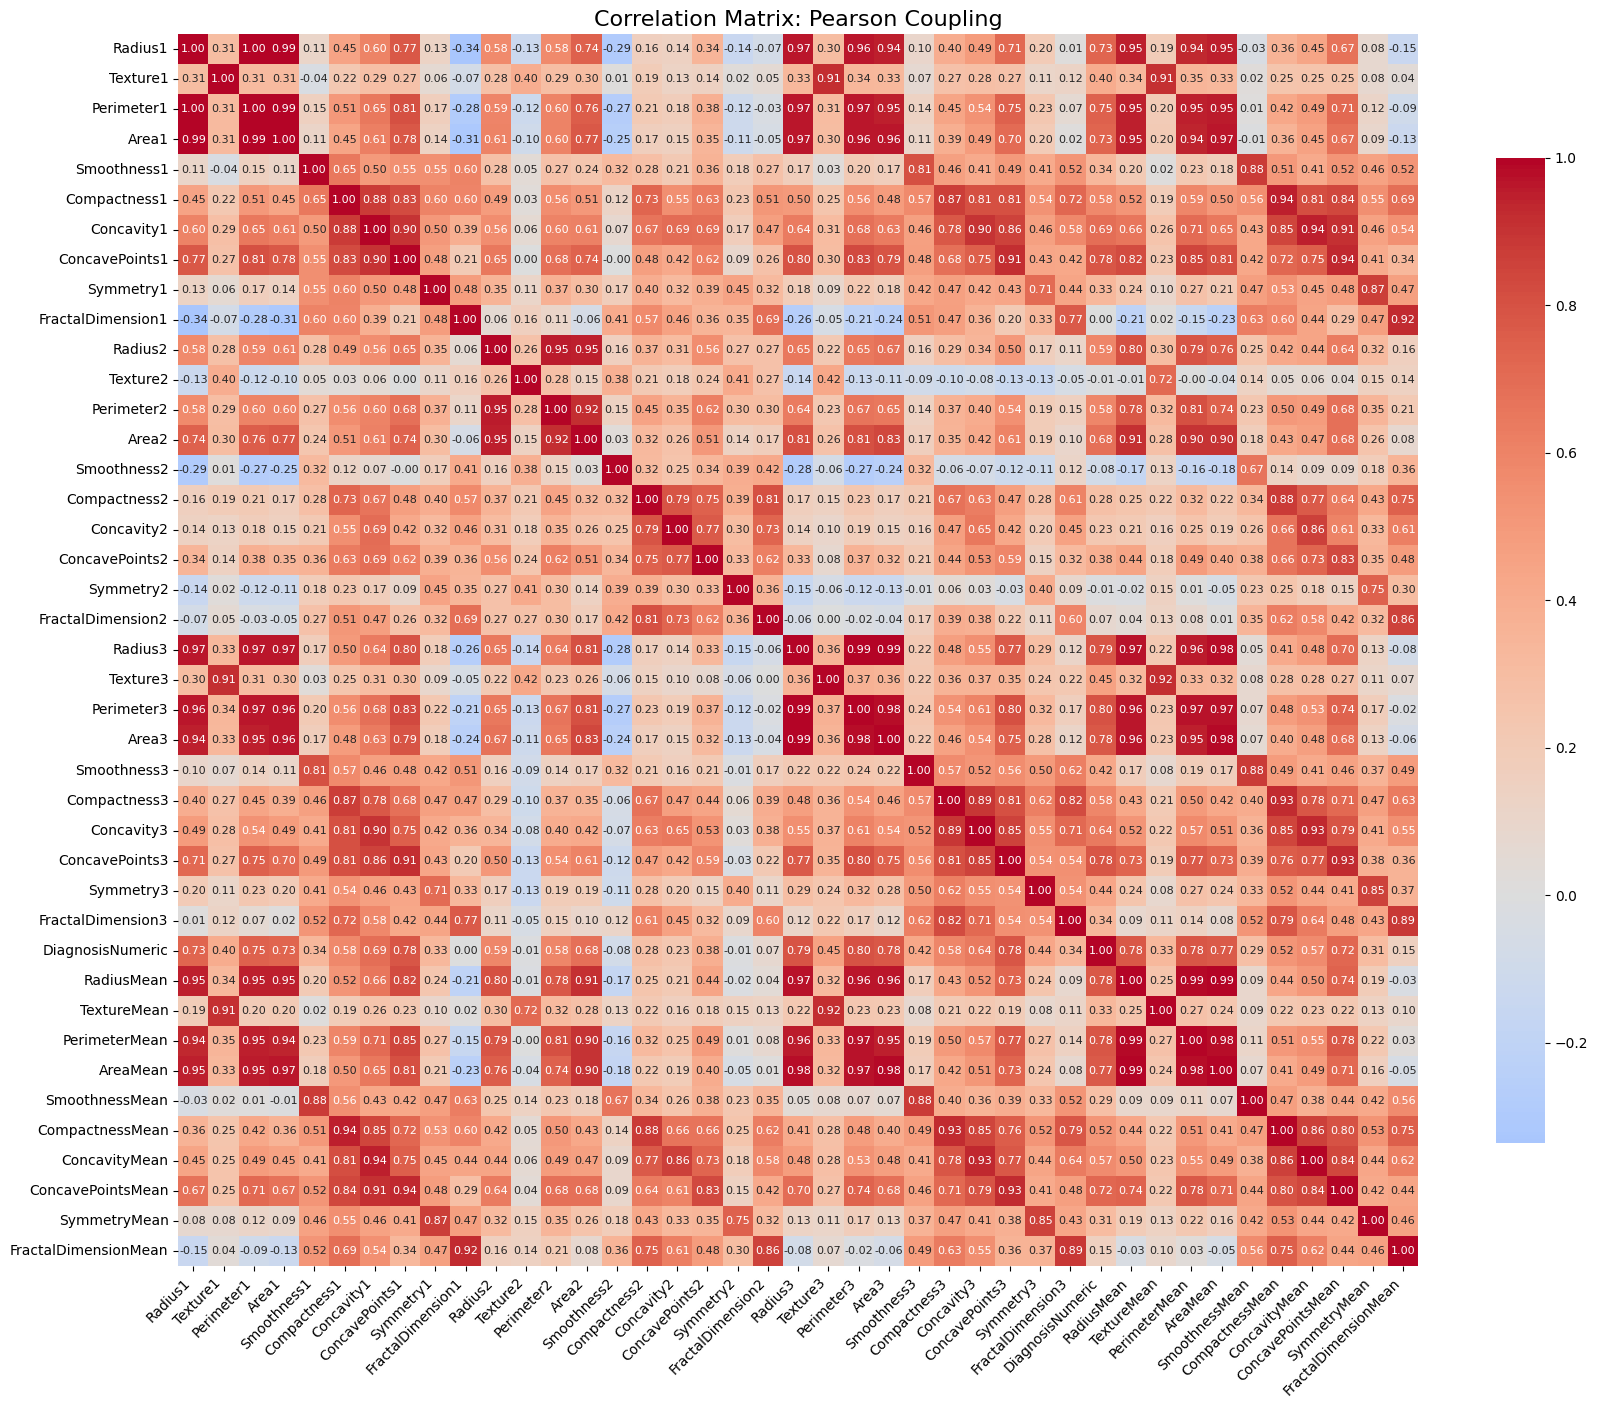

13. Matriz de correlación (corr) y heatmap de seaborn generados.
   Top 5 correlaciones más fuertes:
   1. Perimeter1 vs Radius1: corr=0.997308
   2. Radius3 vs Perimeter3: corr=0.992302
   3. Area1 vs Radius1: corr=0.992220
   4. Perimeter1 vs Area1: corr=0.990330
   5. Area3 vs Radius3: corr=0.989820
   Heatmap: ../artifacts/heatmap_pearson.png
   Reporte final: ../artifacts/02_cancer_final_report.json


,FeatureA,FeatureB,Correlation,AbsCorrelation
82,Perimeter1,Radius1,0.997308,0.997308
842,Radius3,Perimeter3,0.992302,0.992302
123,Area1,Radius1,0.992220,0.992220
85,Perimeter1,Area1,0.990330,0.990330
963,Area3,Radius3,0.989820,0.989820


In [25]:
numeric_df = system_df.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()

heatmap_path = plot_correlation_heatmap(system_df, method="pearson")

corr_pairs = corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool)).stack().reset_index()
corr_pairs.columns = ["FeatureA", "FeatureB", "Correlation"]
corr_pairs["AbsCorrelation"] = corr_pairs["Correlation"].abs()

corr_pairs["PairKey"] = corr_pairs.apply(
    lambda row: "__".join(sorted([row["FeatureA"], row["FeatureB"]])),
    axis=1,
)
strongest_top5 = (
    corr_pairs.sort_values("AbsCorrelation", ascending=False)
    .drop_duplicates(subset=["PairKey"])
    .head(5)
    .drop(columns=["PairKey"])
)

final_report = {
    "OutliersRemoved": int(outliers_removed_count),
    "OutlierDetail": {
        "IqrOutliers": int(len(iqr_outliers)),
        "ZscoreOutliers": int(len(z_outliers)),
        "CombinedOutliers": int(len(combined_outliers)),
    },
    "Top5StrongestCorrelations": [
        {
            "FeatureA": str(row.FeatureA),
            "FeatureB": str(row.FeatureB),
            "Correlation": float(row.Correlation),
            "AbsCorrelation": float(row.AbsCorrelation),
        }
        for row in strongest_top5.itertuples(index=False)
    ],
}

artifact_dir_candidates = [Path("artifacts"), Path("../artifacts")]
artifact_dir = next((p for p in artifact_dir_candidates if p.exists()), artifact_dir_candidates[0])
final_report_path = artifact_dir / "02_cancer_final_report.json"
with open(final_report_path, "w", encoding="utf-8") as f:
    json.dump(final_report, f, indent=2, ensure_ascii=False)

print("13. Matriz de correlación (corr) y heatmap de seaborn generados.")
print("   Top 5 correlaciones más fuertes:")
for i, row in enumerate(strongest_top5.itertuples(index=False), start=1):
    print(f"   {i}. {row.FeatureA} vs {row.FeatureB}: corr={row.Correlation:.6f}")
print(f"   Heatmap: {heatmap_path}")
print(f"   Reporte final: {final_report_path}")
display(strongest_top5)

> 14. ¿Que otro tipo de gráficos pueden ser realizados para entender mejor los datos?
"> 
"> Además del histograma, violín y heatmap, se pueden usar: pairplot (relaciones bivariadas), boxplot/boxenplot (dispersión robusta), KDE por clase (densidades), scatter con reducción PCA/UMAP (separabilidad en baja dimensión), y clustermap (estructura de bloques de correlación).

In [26]:
print("14. Otros gráficos recomendados para entender mejor los datos:")
print("   1) pairplot para relaciones bivariadas por clase.")
print("   2) boxplot y boxenplot para comparar dispersión robusta.")
print("   3) KDE por clase para contrastar densidades.")
print("   4) PCA/UMAP con scatter para visualizar separabilidad.")
print("   5) clustermap para detectar bloques de correlación.")

14. Otros gráficos recomendados para entender mejor los datos:
   1) pairplot para relaciones bivariadas por clase.
   2) boxplot y boxenplot para comparar dispersión robusta.
   3) KDE por clase para contrastar densidades.
   4) PCA/UMAP con scatter para visualizar separabilidad.
   5) clustermap para detectar bloques de correlación.
